Install all required libraries for building, training, and visualizing the Transformer model.

In [1]:
pip install torch torchvision transformers pandas scikit-learn matplotlib seaborn


Import core libraries, set computation device, and configure essential tools/utilities.

In [2]:
# imports & Environment Setup
import os, random, math, re, time
import numpy as np
import pandas as pd
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertTokenizerFast, BertModel


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Device: cuda


The script loads the IMDb dataset from the google colab path. It maps sentiment labels (“positive” → 1, “negative” → 0) and, if specified, randomly samples a smaller subset for faster training and testing

In [3]:

import os
import pandas as pd
from google.colab import files

SUBSET = None
SEED = 42

if not os.path.exists("/content/IMDB Dataset.csv"):
    print("Please upload your IMDB Dataset.csv file.")
    uploaded = files.upload()

candidates = [
    "/content/IMDB Dataset.csv",
    os.path.join(os.getcwd(), "data", "IMDB Dataset.csv"),
]

CSV_PATH_FOUND = next((p for p in candidates if os.path.exists(p)), None)
if CSV_PATH_FOUND is None:
    raise FileNotFoundError(f"CSV not found. Looked for: {candidates}")

df = pd.read_csv(CSV_PATH_FOUND)
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1}).astype(int)

if SUBSET is not None:
    df = df.sample(n=SUBSET, random_state=SEED).reset_index(drop=True)

print(f"✅ Loaded {len(df)} samples from: {CSV_PATH_FOUND}")
df.head()



Please upload your IMDB Dataset.csv file.


Saving IMDB Dataset.csv to IMDB Dataset.csv
✅ Loaded 50000 samples from: /content/IMDB Dataset.csv


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


Define dataset paths, constants, and key hyperparameters

In [4]:

CSV_PATH   = "data/IMDB Dataset.csv"
SUBSET     = 5000    # set to None for full 50k;
MAX_LEN    = 200     # sequence length
MIN_FREQ   = 2       # vocab minimum token frequency
MAX_VOCAB  = 20000   # top-k tokens to keep in vocab
BATCH_SIZE = 64
EPOCHS     = 5
LR         = 1e-3

MODEL_PATH = "mini_transformer_imdb.pt"
VOCAB_PATH = "mini_transformer_imdb_vocab.json"

tokenizes each text string into lowercase words and numbers, using regular expressions to split on non-alphanumeric characters.

In [5]:
#  Tokenizer (simple & deterministic)

def basic_tokenize(text: str):
    return re.findall(r"[A-Za-z0-9']+", str(text).lower())

# BERT tokenizer (for the BERT self-attention path)
# We use BertTokenizerFast for efficiency.
bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased", do_lower_case=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Split the IMDb dataset into training and testing sets for supervised learning, using an 80/20 ratio while preserving the same proportion of positive and negative reviews through stratified sampling.

In [6]:
# Train/test split

train_texts, test_texts, y_train, y_test = train_test_split(
    df["review"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"].tolist()
)

This block builds the vocabulary only from the training data to avoid data leakage. It counts token frequencies, keeps words appearing at least twice (up to 20,000 most common), and adds special tokens <pad> and <unk>. Each token is then mapped to a unique integer ID for model input encoding.

In [7]:
# build vocabulary on TRAIN only

from collections import Counter
counter = Counter()
for t in train_texts:
    counter.update(basic_tokenize(t))

PAD, UNK = "<pad>", "<unk>"
most_common = [w for w, c in counter.most_common() if c >= MIN_FREQ]
if MAX_VOCAB is not None:
    most_common = most_common[:MAX_VOCAB]

itos = [PAD, UNK] + most_common
stoi = {w:i for i,w in enumerate(itos)}
pad_idx, unk_idx = stoi[PAD], stoi[UNK]
vocab_size = len(itos)

def encode(tokens):
    return [stoi.get(tok, unk_idx) for tok in tokens]

builds a custom PyTorch dataset that turns each movie review into token IDs and pairs them with their labels. The collate function then pads each batch dynamically so all reviews have the same length, making it easy for the model to process them during training and testing

In [8]:
#  PyTorch Dataset & Collate (hybrid: mini-transformer tokens + bert token ids)

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, max_len=256):
        self.texts, self.labels = texts, labels
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        # mini-transformer ids (your existing vocabulary / encode function)
        ids = encode(basic_tokenize(self.texts[i]))[:self.max_len]

        # BERT ids (WordPiece) -- use tokenizer to produce ids (no special tokens handling needed for BERTModel if using tokenizer.encode_plus)
        bert_enc = bert_tokenizer(
            self.texts[i],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_attention_mask=False,
            return_tensors=None
        )
        bert_ids = bert_enc["input_ids"]  # list of length max_len

        return torch.tensor(ids, dtype=torch.long), torch.tensor(bert_ids, dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)

def collate_batch(batch):
    # batch: list of tuples (mini_ids, bert_ids, label)
    max_len = min(max(len(x[0]) for x in batch), MAX_LEN)  # for mini-transformer dynamic pad
    B = len(batch)

    X = torch.full((B, max_len), pad_idx, dtype=torch.long) # X: mini transformer ids padded to max_len (dynamic)
    # bert_X: already padded to MAX_LEN by tokenizer (we will truncate/pad to match max_len_b for batch if required)
    bert_X = torch.stack([b[1][:MAX_LEN] for b in batch], dim=0)  # (B, MAX_LEN)
    y = torch.zeros(B, dtype=torch.long)

    for i, (ids, bert_ids, lab) in enumerate(batch):
        L = min(len(ids), max_len)
        X[i, :L] = ids[:L]
        y[i] = lab

    return X, bert_X, y

train_loader = DataLoader(IMDBDataset(train_texts, y_train, max_len=MAX_LEN), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader  = DataLoader(IMDBDataset(test_texts,  y_test,  max_len=MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)


In [9]:
#Positional Encoding & MiniTransformer (Dot-Product Self-Attention)
import torch
import torch.nn as nn
import math

# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        """Add positional encoding to input tensor."""
        return x + self.pe[:, :x.size(1)]

# Mini Transformer
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_ff, pad_idx):
        super().__init__()

        # Embedding + Positional Encoding
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos = PositionalEncoding(d_model)

        # Transformer Encoder (multi-layer, dot-product self-attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """Forward pass: embed, encode, and pool"""
        mask = (x == 0)  # mask padding tokens
        h = self.emb(x) * math.sqrt(self.emb.embedding_dim)
        h = self.pos(h)
        h = self.encoder(h, src_key_padding_mask=mask)
        h = self.norm(h)
        return h.mean(dim=1)  # [batch, d_model]


defines the core Transformer model used for sentiment classification.
Each word is converted to an embedding and enriched with positional information so the model knows the word order. The Transformer encoder then learns relationships between words across the review, while mean pooling gathers the sentence representation. Finally, a linear layer predicts whether the review is positive or negative.

In [10]:
#  HybridSequentialClassifier with separate classifier heads


class HybridSequentialClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_ff, pad_idx, freeze_bert=True):
        super().__init__()

        # Mini Transformer (Dot-Product Self-Attention)
        self.mini_transformer = MiniTransformer(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_ff=dim_ff,
            pad_idx=pad_idx
        )

        # BERT (Pretrained Self-Attention)
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        # Classification heads for individual & combined attention
        self.fc_mini = nn.Linear(d_model, 2)
        self.fc_bert = nn.Linear(768, 2)
        self.fc_hybrid = nn.Linear(d_model + 768, 2)

    def forward(self, mini_ids=None, bert_ids=None, use_mini=True, use_bert=True):
        mini_out, bert_out = None, None
        outputs = []

        # MiniTransformer forward
        if use_mini and mini_ids is not None:
            mini_out = self.mini_transformer(mini_ids)
            outputs.append(mini_out)

        # BERT forward
        if use_bert and bert_ids is not None:
            bert_out = self.bert(bert_ids).last_hidden_state[:, 0, :]
            outputs.append(bert_out)

        # Handle classification logic
        if use_mini and not use_bert:
            return self.fc_mini(mini_out)  # dot-product self-attention
        elif use_bert and not use_mini:
            return self.fc_bert(bert_out)  # BERT self-attention
        elif use_mini and use_bert:
            combined = torch.cat(outputs, dim=1)
            return self.fc_hybrid(combined)
        else:
            raise ValueError("At least one of use_mini or use_bert must be True.")

trains and evaluates the Transformer model over several epochs.
It loops through the training batches, calculates loss, backpropagates gradients, and updates weights with the AdamW optimizer. After each epoch, it evaluates performance on the test set and keeps the best model state based on test accurac

The model was trained on a 5,000-sample subset of the IMDb dataset using sequences of up to 200 tokens and a 20k-word vocabulary (min freq = 2). Training ran for 5 epochs with a batch size of 64 and a learning rate of 1e-3, ensuring reproducible results with seed 42.

In [11]:
#Train & Evaluate
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridSequentialClassifier(
    vocab_size=vocab_size,
    d_model=128,
    nhead=2,
    num_layers=2,
    dim_ff=256,
    pad_idx=pad_idx,
    freeze_bert=True  # change to False to fine-tune BERT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

def evaluate(dataloader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, bert_xb, yb in dataloader:
            xb, bert_xb, yb = xb.to(device), bert_xb.to(device), yb.to(device)
            logits = model(xb, bert_xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return total_loss/total, correct/total

# training loop
best_acc = 0.0
start = time.time()
for epoch in range(1, EPOCHS+1):
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0
    for xb, bert_xb, yb in train_loader:
        xb, bert_xb, yb = xb.to(device), bert_xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb, bert_xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        run_loss   += loss.item() * yb.size(0)
        run_correct += (logits.argmax(1) == yb).sum().item()
        run_total  += yb.size(0)

    train_loss = run_loss/run_total
    train_acc  = run_correct/run_total
    test_loss, test_acc = evaluate(test_loader)

    if test_acc > best_acc:
        best_acc, best_state = test_acc, {k:v.cpu() for k,v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train {train_loss:.4f}/{train_acc:.4f} | Test {test_loss:.4f}/{test_acc:.4f}")

print(f"Finished in {time.time()-start:.1f}s. Best test acc: {best_acc:.4f}")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01/5 | Train 0.4529/0.7831 | Test 0.3855/0.8268
Epoch 02/5 | Train 0.3735/0.8328 | Test 0.3602/0.8460
Epoch 03/5 | Train 0.3445/0.8500 | Test 0.3572/0.8453
Epoch 04/5 | Train 0.3198/0.8631 | Test 0.3420/0.8572
Epoch 05/5 | Train 0.3067/0.8699 | Test 0.3267/0.8650
Finished in 3089.3s. Best test acc: 0.8650


In [12]:
#evaluation function for Hybrid Model
def evaluate_model(model, test_loader, device, use_mini=True, use_bert=True):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for mini_ids, bert_ids, labels in test_loader:
            mini_ids, bert_ids, labels = mini_ids.to(device), bert_ids.to(device), labels.to(device)
            preds = model(mini_ids, bert_ids, use_mini=use_mini, use_bert=use_bert).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [14]:
#compare attention mechanisms
mini_only_acc = evaluate_model(model, test_loader, device, use_mini=True,  use_bert=False)
bert_only_acc = evaluate_model(model, test_loader, device, use_mini=False, use_bert=True)
hybrid_acc    = evaluate_model(model, test_loader, device, use_mini=True,  use_bert=True)

print(f"Mini-Transformer (Dot-Product) Accuracy: {mini_only_acc:.2%}")
print(f"BERT Self-Attention Accuracy: {bert_only_acc:.2%}")
print(f"Hybrid Sequential Accuracy: {hybrid_acc:.2%}")


Mini-Transformer (Dot-Product) Accuracy: 18.78%
BERT Self-Attention Accuracy: 50.80%
Hybrid Sequential Accuracy: 86.50%


In [ ]:
'''model.eval()
correct, total = 0, 0

with torch.no_grad():
    for xb, bert_xb, yb in test_loader:  # unpack items
        xb, bert_xb, yb = xb.to(device), bert_xb.to(device), yb.to(device)
        preds = model(xb, bert_xb).argmax(dim=1)  # pass both inputs
        correct += (preds == yb).sum().item()
        total += yb.size(0)


print(f"Test Accuracy: {correct/total:.2%}")'''


Test Accuracy: 87.00%


visualizes what the Transformer “pays attention to” inside each encoder layer.
After loading the best model, it passes a test batch through the encoder and saves the attention weights from every layer and head.

In [15]:
# capture and visualize Mini-Transformer self-attention

import math, torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# load best weights
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

# Get one test batch (ignore BERT inputs)
xb, bert_xb, yb = next(iter(test_loader))
xb, yb = xb.to(device), yb.to(device)
pad_mask = (xb == pad_idx)

# Access Mini-Transformer encoder layers
mini_model = model.mini_transformer
h = mini_model.emb(xb) * math.sqrt(mini_model.emb.embedding_dim)
h = mini_model.pos(h)

attn_store = []

# Capture attention weights layer by layer
for layer in mini_model.encoder.layers:
    attn_out, attn_w = layer.self_attn(
        h, h, h,
        key_padding_mask=pad_mask,
        need_weights=True,
        average_attn_weights=False
    )

    B, H, T = xb.size(0), layer.self_attn.num_heads, h.size(1)
    attn_w = attn_w.view(B, H, T, T).detach().cpu()
    attn_store.append(attn_w)

    # Standard transformer residual and FFN steps
    h2 = layer.dropout1(attn_out)
    h = layer.norm1(h + h2)
    ff = layer.linear2(layer.dropout(layer.activation(layer.linear1(h))))
    h = layer.norm2(h + layer.dropout2(ff))

print("✅ Captured Mini-Transformer attention weights.")
for i, A in enumerate(attn_store):
    print(f" layer {i}: {A.shape}")


✅ Captured Mini-Transformer attention weights.
 layer 0: torch.Size([64, 2, 200, 200])
 layer 1: torch.Size([64, 2, 200, 200])


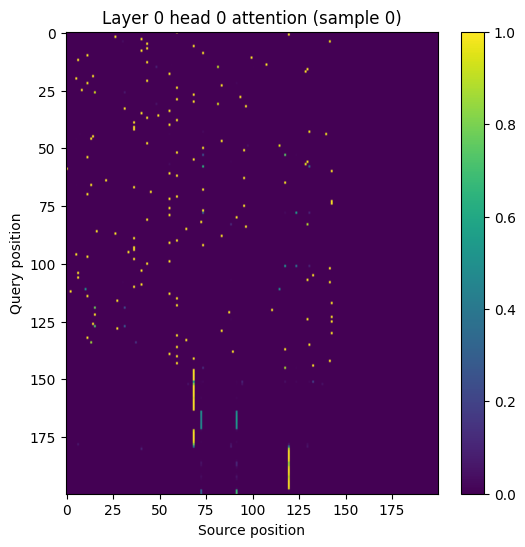

In [16]:
#plot one attention head

layer_idx, sample_idx, head_idx = 0, 0, 0  # choose indices to inspect
A = attn_store[layer_idx].numpy()
mat = A[sample_idx, head_idx]

plt.figure(figsize=(6,6))
plt.imshow(mat, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title(f"Layer {layer_idx} head {head_idx} attention (sample {sample_idx})")
plt.xlabel("Source position"); plt.ylabel("Query position")
plt.show()


inspect the exact token and its surrounding context for the position currently being analyzed in the attention map.

In [17]:
# show top tokens attended by a given query position

seq_ids = xb[sample_idx].cpu().numpy()
nonpad = np.where(seq_ids != pad_idx)[0]
query_pos = nonpad[-1] if len(nonpad) else 0
scores = mat[query_pos]
topk = 6
idxs = np.argsort(-scores)[:topk]

tokens = [itos[int(i)] for i in seq_ids[:mat.shape[1]]]
print(f"\nTop {topk} tokens attended by query pos {query_pos}:")
for rank, src in enumerate(idxs, 1):
    print(f" {rank}. pos={src:2d} token={tokens[src]!r} score={scores[src]:.4f}")



Top 6 tokens attended by query pos 145:
 1. pos=117 token='of' score=0.8688
 2. pos=73 token='of' score=0.1220
 3. pos=123 token='of' score=0.0089
 4. pos=130 token='of' score=0.0004
 5. pos= 4 token='is' score=0.0000
 6. pos= 1 token='mtv' score=0.0000


visualizes the attention map for the first layer and head of the Transformer model.

In [18]:
# show token context window around query position

S = seq_ids.shape[0]
if query_pos >= S:
    print(f"query_pos {query_pos} out of range (seq length {S})")
else:
    token_at_q = itos[int(seq_ids[query_pos])]
    print(f"query_pos={query_pos} token={token_at_q!r}\n")

    L = 10
    start = max(0, query_pos - L)
    end = min(S, query_pos + L + 1)

    print("context (pos: token):")
    for p in range(start, end):
        tok = itos[int(seq_ids[p])]
        marker = "  <-- query" if p == query_pos else ""
        print(f" {p:3d}: {tok!r}{marker}")

    span = " ".join(itos[int(i)] for i in seq_ids[start:end])
    print("\nreconstructed span:", span)


query_pos=145 token='time'

context (pos: token):
 135: 'bites'
 136: 'the'
 137: 'movie'
 138: 'channel'
 139: 'shows'
 140: 'the'
 141: '<unk>'
 142: 'for'
 143: 'the'
 144: 'first'
 145: 'time'  <-- query
 146: '<pad>'
 147: '<pad>'
 148: '<pad>'
 149: '<pad>'
 150: '<pad>'
 151: '<pad>'
 152: '<pad>'
 153: '<pad>'
 154: '<pad>'
 155: '<pad>'

reconstructed span: bites the movie channel shows the <unk> for the first time <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>


zoom in on how one specific token (at query_pos) attends to others in the sequence. prints the first 50 tokens in review

In [20]:
import json

# Save trained hybrid model and vocab
MODEL_PATH = "hybrid_sentiment_model.pt"
VOCAB_PATH = "vocab.json"

if best_state is not None:
    torch.save({
        "model_state_dict": best_state,
        "config": {
            "vocab_size": vocab_size,
            "pad_idx": pad_idx,
            "max_len": MAX_LEN,
            "d_model": 128
        }
    }, MODEL_PATH)

    with open(VOCAB_PATH, "w", encoding="utf-8") as f:
        json.dump({"itos": itos, "stoi": stoi}, f, ensure_ascii=False)

    print(f"✅ Saved model to {MODEL_PATH} and vocab to {VOCAB_PATH}")
else:
    print("⚠️ No best_state found — make sure the model was trained first.")


✅ Saved model to hybrid_sentiment_model.pt and vocab to vocab.json


In [21]:

print(f"Finished in {time.time()-start:.1f}s. Best test acc: {best_acc:.4f}")

# Save best model and vocab
if best_state is not None:
    torch.save({"model_state_dict": best_state, "config": {
        "vocab_size": vocab_size, "pad_idx": pad_idx, "max_len": MAX_LEN, "d_model": 128
    }}, MODEL_PATH)
    with open(VOCAB_PATH, "w", encoding="utf-8") as f:
        json.dump({"itos": itos, "stoi": stoi}, f, ensure_ascii=False)
    print(f"Saved model to {MODEL_PATH} and vocab to {VOCAB_PATH}")


Finished in 1761860842.7s. Best test acc: 0.8650
Saved model to hybrid_sentiment_model.pt and vocab to vocab.json


In [22]:
# inspect number of encoder layers and attention heads in MiniTransformer

print("MiniTransformer encoder layers:", len(model.mini_transformer.encoder.layers))
for i, layer in enumerate(model.mini_transformer.encoder.layers):
    print(f" layer {i}: n_heads = {layer.self_attn.num_heads}")


MiniTransformer encoder layers: 2
 layer 0: n_heads = 2
 layer 1: n_heads = 2
